In [ ]:
# E-Commerce Orders Analysis

This project analyzes order and product data to evaluate:
- revenue performance
- return rates
- shipping efficiency
- product performance
    
Tools used:
- SQL (data extraction)
- Python (analysis & feature engineering)
- Tableau (dashboarding)

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("ecommerce.db")

In [20]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
orders = pd.read_sql_query("SELECT * FROM orders", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)

In [4]:
orders.head()
products.head()

,product_id,product_name,product_category,manufacturing_city,size,color,SKU,cost,launch_date
0,924197,Product_924197,Home,New York,L,Blue,40138388,74.21,2023-11-24 16:35:07.864252
1,562958,Product_562958,Electronics,Seattle,S,Gray,12407626,21.14,2024-10-14 16:35:07.864286
2,381632,Product_381632,Home,Phoenix,S,White,45607312,86.93,2024-10-27 16:35:07.864300
3,363028,Product_363028,Apparel,New York,S,Blue,29697412,90.13,2023-10-06 16:35:07.864310
4,176588,Product_176588,Electronics,Phoenix,S,White,75094386,57.03,2025-03-03 16:35:07.864319


In [5]:
orders.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       4998 non-null   int64  
 1   product_id     4998 non-null   int64  
 2   customer_id    4998 non-null   int64  
 3   price          4998 non-null   float64
 4   order_date     4998 non-null   object 
 5   shipping_date  4998 non-null   object 
 6   quantity       4998 non-null   int64  
 7   discount       4998 non-null   float64
 8   shipping_cost  4998 non-null   float64
 9   order_status   4998 non-null   object 
dtypes: float64(3), int64(4), object(3)
memory usage: 390.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          20 non-null     int64  
 1   product_name        20 non-null     object 
 2 

In [21]:
orders.describe()

,order_id,product_id,customer_id,price,quantity,discount,shipping_cost
count,"4,998.00","4,998.00","4,998.00","4,998.00","4,998.00","4,998.00","4,998.00"
mean,"5,507,847.75","505,853.66","54,466.59",253.46,2.53,0.15,14.93
std,"2,581,219.46","253,748.24","25,964.50",141.86,1.12,0.09,5.76
min,"1,001,647.00","140,937.00","10,022.00",10.05,1.00,0.00,5.00
25%,"3,307,787.00","313,802.00","31,535.50",128.79,2.00,0.08,9.96
50%,"5,437,991.50","492,904.00","54,213.00",256.89,3.00,0.15,14.96
75%,"7,758,411.75","720,230.00","76,567.00",374.76,4.00,0.23,19.86
max,"9,996,972.00","938,521.00","99,979.00",499.98,4.00,0.30,25.00


In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["shipping_date"] = pd.to_datetime(orders["shipping_date"])
                                

In [8]:
df = orders.merge(products, on="product_id", how="left")

In [9]:
df["shipping_days"] = (df["shipping_date"] - df["order_date"]).dt.days

In [10]:
df["net_price"] = df["price"] * (1 - df["discount"])

In [11]:
df["revenue"] = df["net_price"] * df["quantity"]

In [12]:
df["profit"] = (df["net_price"] - df["cost"]) * df["quantity"]

In [22]:
df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

product_category
Electronics   1,240,347.79
Home            746,001.71
Apparel         385,287.92
Beauty          180,136.26
Sports          175,804.97
Name: revenue, dtype: float64

In [14]:
df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10)

product_name
Product_512461    213522.4350
Product_363028    201518.9367
Product_938521    192438.4819
Product_674253    191200.0860
Product_781209    183768.9809
Product_328815    181360.0744
Product_924197    180929.9370
Product_720230    180136.2563
Product_562958    177549.7315
Product_313802    176871.3030
Name: revenue, dtype: float64

In [15]:
df["is_returned"] = (df["order_status"] == "Returned").astype(int)

df.groupby("product_category")["is_returned"].mean() * 100

product_category
Apparel        25.553914
Beauty         24.233129
Electronics    23.638721
Home           24.576895
Sports         26.708075
Name: is_returned, dtype: float64

In [16]:
df.groupby("product_category")["shipping_days"].mean()

product_category
Apparel        5.184638
Beauty         5.098160
Electronics    4.976664
Home           4.935247
Sports         4.742236
Name: shipping_days, dtype: float64

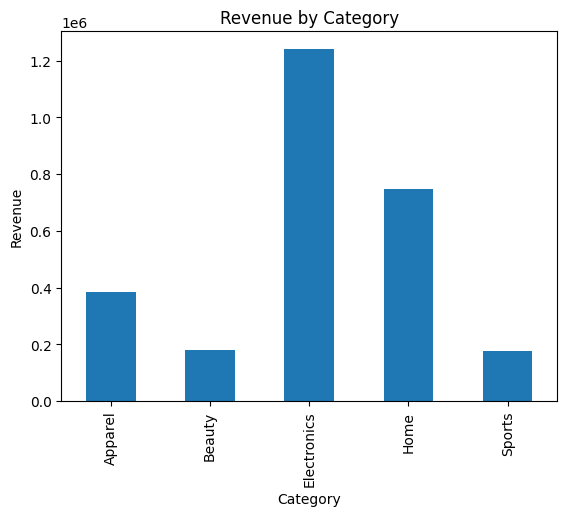

In [24]:
df.groupby("product_category")["revenue"].sum().plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

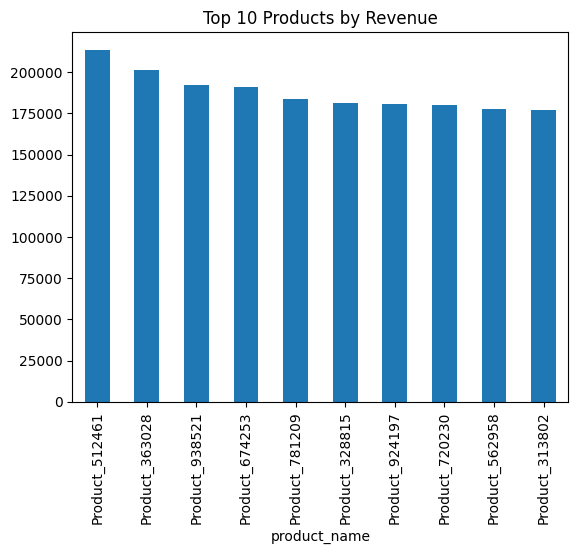

In [25]:
df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.show()

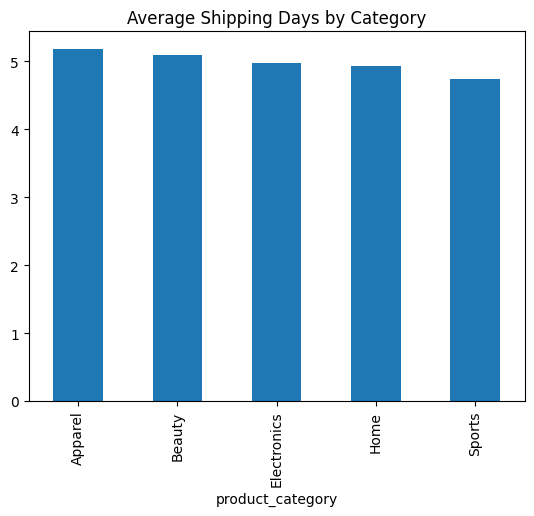

In [27]:
df.groupby("product_category")["shipping_days"].mean().plot(kind="bar")

plt.title("Average Shipping Days by Category")
plt.show()

In [ ]:
## Key Insights

- Electronics generate the highest revenue across all categories
- Some categories show longer shipping times, which may impact customer satisfaction
- Revenue is concentrated among a small number of products

In [26]:
df.to_csv("ecommerce_cleaned.csv", index=False)